General Summary-
This project analyzes one year of online retail transaction data to understand sales performance and identify business trends.
Using Python and pandas, I cleaned the dataset, analyzed revenue, explored top-selling products, compared revenue across countries, and examined monthly sales trends.
The analysis found that the business generated $10.67 million in revenue, with the United Kingdom being the largest market
and November 2011 having the highest monthly revenue.
The project also identifies top-performing products and provides business recommendations based on the findings.


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_excel("/content/Online Retail.xlsx")

# Show the first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# See the size of the dataset
print("Rows and columns;", df.shape)

# See the column names
print("\nColumns:")
print(df.columns.tolist())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Rows and columns; (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [3]:
# Look at bsic information about dataset
df.info()

# Check the basic statistic for numerical columns
df.describe()

# Check the date range
print("Earliest transcation:", df["InvoiceDate"].min())
print("Latest transcation:", df["InvoiceDate"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
Earliest transcation: 2010-12-01 08:26:00
Latest transcation: 2011-12-09 12:50:00


In [4]:
# Find transcations with negative quantities
negative_quantity = df[df["Quantity"] <0]
print("Negative quantity transactions:",len(negative_quantity))

# See some examples
negative_quantity.head()

# Check how many invoices start with "C"
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]
print("Canacelled invoices:", len(cancelled))

Negative quantity transactions: 10624
Canacelled invoices: 9288


In [7]:
# Compare negative quantites with cancelled invoices
print("Negative quantity  transactions:", len(df[df["Quantity"] < 0]))
print("Cancelled transcations:",
      len(df[df["InvoiceNo"].astype(str).str.startswith("C")]))

# Check negative quantities that DON'T have a C invoice
negative_not_cancelled = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

print("Negative quantity without C invoice:",
      len(negative_not_cancelled))

Negative quantity  transactions: 10624
Cancelled transcations: 9288
Negative quantity without C invoice: 1336


In [9]:
# Look at those unusual transcations
negative_not_cancelled.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [10]:
clean_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

print("Original rows:", len(df))
print("Clean sales rows:", len(clean_df))

Original rows: 541909
Clean sales rows: 530104


In [13]:
# How much revenue did the company generate from these sales?
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]
print("Total Revenue: $", round(clean_df["Revenue"].sum(), 2))

# What are our top 10 products by quantity sold?
top_products = (
    clean_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products)

Total Revenue: $ 10666684.54
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


In [15]:
# Which 10 products generated the most revenue?
top_revenue_products = (
    clean_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_revenue_products)

# Which actual products are with the highest revenue?
product_revenue = (
    clean_df[
        ~clean_df["Description"].isin([
            "DOTCOM POSTAGE",
            "POSTAGE",
            "Manual"
        ])
    ]
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(product_revenue)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64
Description
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66964.99
PAPER CHAIN KIT 50'S CHRISTMAS         64952.29
ASSORTED COLOUR BIRD ORNAMENT          59094.93
CHILLI LIGHTS                     

In [16]:
# Which month had the highest revenue?
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M")
monthly_revenue =(
    clean_df.groupby("Month")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(monthly_revenue)

Month
2011-11    1509496.330
2011-10    1154979.300
2011-09    1058590.172
2010-12     823746.140
2011-05     770536.020
2011-06     761739.900
2011-08     759138.380
2011-07     719221.191
2011-03     717639.360
2011-01     691364.560
2011-12     638792.680
2011-04     537808.621
2011-02     523631.890
Freq: M, Name: Revenue, dtype: float64


In [18]:
# How much does the average customer order spend?
average_order = clean_df.groupby("InvoiceNo")["Revenue"].sum().mean()
print("Average Order Value: $", round(average_order, 2))

# Which countries generate the most revenue?
country_revenue = (
    clean_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(country_revenue)

Average Order Value: $ 534.4
Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


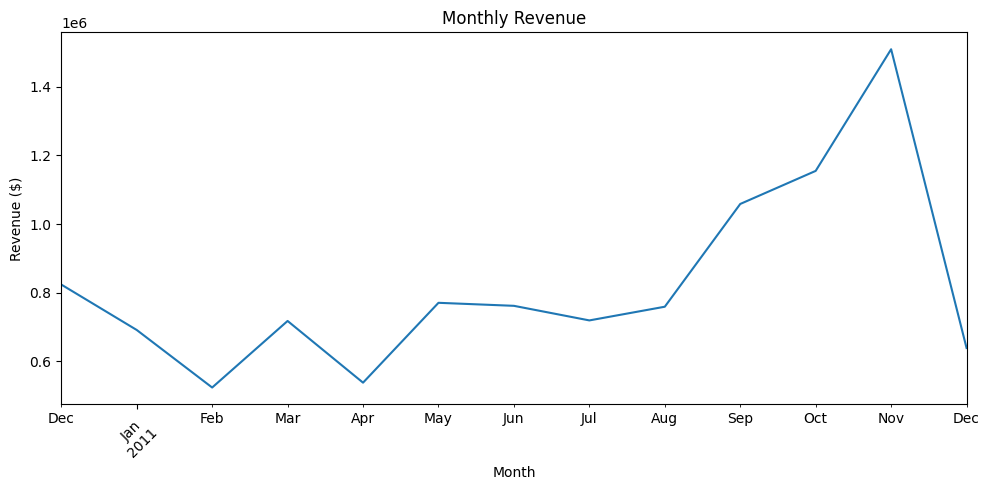

In [20]:
import matplotlib.pyplot as plt
monthly_revenue_sorted = monthly_revenue.sort_index()
monthly_revenue_sorted.plot(kind="line", figsize=(10,5))

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Final question: What should the business do?
'''
1. Focus on top performing products
The Regency Cakestand 3 Tier and Paper Craft, Little Birdie generated the most
product revenue, so the company should make sure the these products stay well-stocked.
2. Prepare for the holiday season
Revenue increased significantly from September through November, so the company
should preapre inventory and staffing ahead of this period.
3. Expan international sales
The UK generated about 85% of revenue, while other countries contributed much less.
The company should explore marketing and sales opportunities in countries such as
the Netherlands, Germany, and France.

'''
